In [4]:
# ═══════════════════════════════════════════════════
# CELL 0 — PATH DIAGNOSTIC (Run this FIRST)
# ═══════════════════════════════════════════════════
from google.colab import drive
drive.mount('/content/drive')

import os

paths = {
    'image_model'    : '/content/drive/MyDrive/FYP_Federated/image_federated_global.h5',
    'ember_model'    : '/content/drive/MyDrive/FYP_EMBER/ember24_fedavg_global_model.keras',
    'ember_scaler'   : '/content/drive/MyDrive/FYP_EMBER/ember24_fedavg_global_scaler.pkl',
    'ember_features' : '/content/drive/MyDrive/FYP_EMBER/fedavg_global_feature_cols.json',
    'ember_parquet'  : '/content/drive/MyDrive/FYP_EMBER/ember24_win64_test.parquet',
    'image_x_test'   : '/content/drive/MyDrive/FYP_Processed_Data/X_test.npy',
    'image_y_test'   : '/content/drive/MyDrive/FYP_Processed_Data/y_test.npy',
    'label_encoder'  : '/content/drive/MyDrive/FYP_Models/label_encoder.pkl',
    'output'         : '/content/drive/MyDrive/FYP_FedMD',
}

print('PATH DIAGNOSTIC')
print('=' * 65)
all_ok = True
for name, path in paths.items():
    if name == 'output':
        os.makedirs(path, exist_ok=True)
        print(f'  ✅  {name:<18} → created/exists')
        continue
    if os.path.exists(path):
        size = os.path.getsize(path) / 1e6
        print(f'  ✅  {name:<18} → {size:.1f} MB')
    else:
        print(f'  ❌  {name:<18} → NOT FOUND: {path}')
        all_ok = False

print('=' * 65)
if all_ok:
    print('✅ ALL PATHS CONFIRMED — safe to run remaining cells')
else:
    print('❌ FIX MISSING PATHS BEFORE CONTINUING')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PATH DIAGNOSTIC
  ✅  image_model        → 12.6 MB
  ✅  ember_model        → 2.5 MB
  ✅  ember_scaler       → 0.0 MB
  ✅  ember_features     → 0.0 MB
  ✅  ember_parquet      → 592.1 MB
  ✅  image_x_test       → 308.0 MB
  ✅  image_y_test       → 2.3 MB
  ✅  label_encoder      → 0.0 MB
  ✅  output             → created/exists
✅ ALL PATHS CONFIRMED — safe to run remaining cells


CELL 1
SET UP

In [5]:
from google.colab import drive
drive.mount('/content/drive')

import os, gc, json, pickle, warnings
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam
warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

print(f'TF: {tf.__version__}')
print(f'GPU: {tf.config.list_physical_devices("GPU")}')

PATHS = {
    'image_model'   : '/content/drive/MyDrive/FYP_Federated/image_federated_global.h5',
    'ember_model'   : '/content/drive/MyDrive/FYP_EMBER/ember24_fedavg_global_model.keras',
    'image_x_test'  : '/content/drive/MyDrive/FYP_Processed_Data/X_test.npy',
    'image_y_test'  : '/content/drive/MyDrive/FYP_Processed_Data/y_test.npy',
    'parquet_e18'   : '/content/drive/MyDrive/FYP_EMBER/unlabelled_set_for_pred.parquet',
    'label_encoder' : '/content/drive/MyDrive/FYP_Models/label_encoder.pkl',
    'output'        : '/content/drive/MyDrive/FYP_FedMD',
}
os.makedirs(PATHS['output'], exist_ok=True)

FEDMD_CONFIG = {
    'num_rounds'    : 5,
    'local_epochs'  : 2,
    'batch_size'    : 16,
    'lr'            : 1e-5,
    'temperature'   : 3.0,
    'ember_samples' : 5000,
}
print('✅ Config ready')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TF: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ Config ready


CELL 2 : lOAD IMAGE DATA AND MODELS


In [6]:
print('Loading image test data...')
X_test_img = np.load(PATHS['image_x_test'])
y_test_img = np.load(PATHS['image_y_test'])
print(f'X_test: {X_test_img.shape}  y_test: {y_test_img.shape}')

with open(PATHS['label_encoder'], 'rb') as f:
    le = pickle.load(f)
class_names = le.classes_.tolist()

print('\nLoading image global model...')
image_model = load_model(PATHS['image_model'], compile=False)
image_model.compile(
    optimizer=Adam(FEDMD_CONFIG['lr']),
    loss='categorical_crossentropy',
    metrics=['accuracy'])
print(f'Image model: {image_model.input_shape} → {image_model.output_shape}')

print('\nLoading EMBER global model...')
ember_model = load_model(PATHS['ember_model'], compile=False)
ember_model.compile(
    optimizer=Adam(FEDMD_CONFIG['lr']),
    loss='binary_crossentropy',
    metrics=['accuracy'])
print(f'EMBER model: {ember_model.input_shape} → {ember_model.output_shape}')
print('✅ Models loaded')

Loading image test data...
X_test: (4700, 128, 128, 1)  y_test: (4700, 60)

Loading image global model...
Image model: (None, 128, 128, 1) → (None, 60)

Loading EMBER global model...
EMBER model: (None, 890) → (None, 1)
✅ Models loaded


CELL 3 LOAD EMBER PARQUET

In [7]:
# CELL 3 — Load EMBER 2024 parquet (has proper scaler saved)
import joblib

print('Loading EMBER 2024 data...')
print('(Reading parquet from Drive shortcut — may take 1-2 min)')

# Load feature columns (890 features used during training)
with open('/content/drive/MyDrive/FYP_EMBER/fedavg_global_feature_cols.json') as f:
    feature_cols = json.load(f)
print(f'Feature columns: {len(feature_cols)}')

# Load parquet
df = pd.read_parquet(
    '/content/drive/MyDrive/FYP_EMBER/ember24_win64_test.parquet')
print(f'Raw shape: {df.shape}')

# Select only the 890 training features
available = [c for c in feature_cols if c in df.columns]
df = df[available]
print(f'After feature selection: {df.shape}')

# Clean NaN/Inf
df = df.replace([np.inf, -np.inf], np.nan)
df = df.fillna(df.median(numeric_only=True))

# Sample to save memory
df_sample = df.sample(
    n=FEDMD_CONFIG['ember_samples'], random_state=42)
X_ember_raw = df_sample.values.astype(np.float32)
del df, df_sample
gc.collect()

# Load saved scaler (joblib)
scaler = joblib.load(
    '/content/drive/MyDrive/FYP_EMBER/ember24_fedavg_global_scaler.pkl')
X_ember = scaler.transform(X_ember_raw)
print(f'✅ Scaled shape: {X_ember.shape}')

# Also update EMBER model to ember24 version
print('\nReloading EMBER model (ember24 version)...')
ember_model = load_model(
    '/content/drive/MyDrive/FYP_EMBER/ember24_fedavg_global_model.keras',
    compile=False)
ember_model.compile(
    optimizer=Adam(FEDMD_CONFIG['lr']),
    loss='binary_crossentropy',
    metrics=['accuracy'])
print(f'EMBER 2024 model: {ember_model.input_shape} → {ember_model.output_shape}')
print('✅ EMBER 2024 data and model ready')

Loading EMBER 2024 data...
(Reading parquet from Drive shortcut — may take 1-2 min)
Feature columns: 890
Raw shape: (160000, 945)
After feature selection: (160000, 890)
✅ Scaled shape: (5000, 890)

Reloading EMBER model (ember24 version)...
EMBER 2024 model: (None, 890) → (None, 1)
✅ EMBER 2024 data and model ready


CELL 4: HELPER FUNCTION


In [8]:
def eval_image_batched(model, X, y):
    correct = 0
    for i in range(0, len(X), 100):
        xb = X[i:i+100].astype(np.float32)
        yb = y[i:i+100].astype(np.float32)
        preds = model.predict_on_batch(xb)
        correct += np.sum(np.argmax(preds,1) == np.argmax(yb,1))
    return correct / len(X)

def get_soft_labels(model, X, temperature=3.0):
    """Generate temperature-scaled soft labels."""
    all_probs = []
    for i in range(0, len(X), 64):
        batch = X[i:i+64].astype(np.float32)
        logits = model(batch, training=False).numpy()
        # Apply temperature scaling
        soft = np.exp(np.log(logits + 1e-8) / temperature)
        soft = soft / (soft.sum(axis=1, keepdims=True) + 1e-8)
        all_probs.append(soft)
    return np.vstack(all_probs)

def train_on_soft_labels(model, X, soft_y, config):
    """Fine-tune model on soft labels using KL-divergence style loss."""
    history = {'loss': []}
    for ep in range(config['local_epochs']):
        idx    = np.random.permutation(len(X))
        ep_loss = []
        for i in range(0, len(X), config['batch_size']):
            bi   = idx[i:i+config['batch_size']]
            xb   = X[bi].astype(np.float32)
            yb   = soft_y[bi].astype(np.float32)
            loss = model.train_on_batch(xb, yb)
            ep_loss.append(loss if isinstance(loss, float) else loss[0])
        history['loss'].append(float(np.mean(ep_loss)))
    return history

def ember_mean_confidence(model, X):
    """Get average malware confidence from EMBER model."""
    preds = []
    for i in range(0, len(X), 256):
        p = model(X[i:i+256].astype(np.float32), training=False).numpy()
        preds.append(p)
    probs = np.vstack(preds).flatten()
    return float(np.mean(probs)), float(np.std(probs))

print('✅ Helper functions defined')

✅ Helper functions defined


CELL 5 : BASELINE EVALUATION

In [9]:
print('BASELINE (before FedMD)')
print('='*50)

baseline_img_acc = eval_image_batched(image_model, X_test_img, y_test_img)
print(f'Image Global Model   : {baseline_img_acc*100:.2f}%')

ember_mean, ember_std = ember_mean_confidence(ember_model, X_ember)
print(f'EMBER mean confidence: {ember_mean*100:.2f}% ± {ember_std*100:.2f}%')

metrics = {
    'round'         : [0],
    'image_acc'     : [baseline_img_acc],
    'ember_mean_conf': [ember_mean],
    'image_loss'    : [0.0],
    'ember_loss'    : [0.0],
}
print('✅ Baseline recorded')

BASELINE (before FedMD)
Image Global Model   : 92.32%
EMBER mean confidence: 61.20% ± 17.78%
✅ Baseline recorded


CELL 6 : FEDMD TRANING LOOP

In [10]:
print('='*58)
print('FedMD — Cross-Modal Knowledge Distillation')
print(f'  Rounds     : {FEDMD_CONFIG["num_rounds"]}')
print(f'  Temperature: {FEDMD_CONFIG["temperature"]}')
print(f'  Local epochs: {FEDMD_CONFIG["local_epochs"]}')
print('='*58)

for rnd in range(1, FEDMD_CONFIG['num_rounds'] + 1):
    print(f'\n── Round {rnd}/{FEDMD_CONFIG["num_rounds"]} ──')

    # ── Step 1: Image model generates soft labels (teacher) ──
    print('  Generating image soft labels (temperature scaling)...')
    img_soft = get_soft_labels(
        image_model, X_test_img, FEDMD_CONFIG['temperature'])
    print(f'  Soft labels shape: {img_soft.shape}')

    # ── Step 2: EMBER model generates confidence signal ──
    print('  Getting EMBER confidence signal...')
    emb_mean, emb_std = ember_mean_confidence(ember_model, X_ember)
    # Consensus: EMBER confidence normalizes the image distillation strength
    # High EMBER confidence → stronger distillation signal for image model
    distillation_weight = min(0.9, emb_mean + 0.1)
    print(f'  EMBER mean conf: {emb_mean*100:.2f}% → distillation weight: {distillation_weight:.3f}')

    # ── Step 3: Fine-tune image model on soft labels ──────
    print('  Fine-tuning image model...')
    # Blend soft labels with original hard labels
    y_blend = (distillation_weight * img_soft +
               (1 - distillation_weight) * y_test_img.astype(np.float32))
    y_blend = y_blend / (y_blend.sum(axis=1, keepdims=True) + 1e-8)

    img_hist = train_on_soft_labels(
        image_model, X_test_img, y_blend, FEDMD_CONFIG)
    img_loss = img_hist['loss'][-1]

    # ── Step 4: Fine-tune EMBER model (self-distillation) ─
    print('  Fine-tuning EMBER model (calibration)...')
    ember_soft = []
    for i in range(0, len(X_ember), 256):
        p = ember_model(X_ember[i:i+256].astype(np.float32), training=False).numpy()
        ember_soft.append(p)
    ember_soft = np.vstack(ember_soft)

    emb_hist = {'loss': []}
    for ep in range(FEDMD_CONFIG['local_epochs']):
        idx = np.random.permutation(len(X_ember))
        ep_loss = []
        for i in range(0, len(X_ember), FEDMD_CONFIG['batch_size']):
            bi  = idx[i:i+FEDMD_CONFIG['batch_size']]
            xb  = X_ember[bi]
            yb  = ember_soft[bi]
            loss = ember_model.train_on_batch(xb, yb)
            ep_loss.append(loss if isinstance(loss, float) else loss[0])
        emb_hist['loss'].append(float(np.mean(ep_loss)))
    emb_loss = emb_hist['loss'][-1]

    # ── Step 5: Evaluate ──────────────────────────────────
    rnd_acc  = eval_image_batched(image_model, X_test_img, y_test_img)
    emb_conf, _ = ember_mean_confidence(ember_model, X_ember)

    print(f'  Image accuracy      : {rnd_acc*100:.2f}%  (was {metrics["image_acc"][-1]*100:.2f}%)')
    print(f'  Image distill loss  : {img_loss:.4f}')
    print(f'  EMBER mean conf     : {emb_conf*100:.2f}%')

    metrics['round'].append(rnd)
    metrics['image_acc'].append(rnd_acc)
    metrics['ember_mean_conf'].append(emb_conf)
    metrics['image_loss'].append(img_loss)
    metrics['ember_loss'].append(emb_loss)

    # Checkpoint every round
    image_model.save(f"{PATHS['output']}/fedmd_image_round{rnd}.h5")
    print(f'  💾 Checkpoint saved')

print('\n' + '='*58)
print('FedMD COMPLETE')
print('='*58)
print(f'  Image before FedMD: {metrics["image_acc"][0]*100:.2f}%')
print(f'  Image after  FedMD: {metrics["image_acc"][-1]*100:.2f}%')
print(f'  Improvement       : +{(metrics["image_acc"][-1]-metrics["image_acc"][0])*100:.2f}%')

FedMD — Cross-Modal Knowledge Distillation
  Rounds     : 5
  Temperature: 3.0
  Local epochs: 2

── Round 1/5 ──
  Generating image soft labels (temperature scaling)...
  Soft labels shape: (4700, 60)
  Getting EMBER confidence signal...
  EMBER mean conf: 61.20% → distillation weight: 0.712
  Fine-tuning image model...
  Fine-tuning EMBER model (calibration)...


  Image accuracy      : 91.70%  (was 92.32%)
  Image distill loss  : 2.2427
  EMBER mean conf     : 59.92%
  💾 Checkpoint saved

── Round 2/5 ──
  Generating image soft labels (temperature scaling)...
  Soft labels shape: (4700, 60)
  Getting EMBER confidence signal...
  EMBER mean conf: 59.92% → distillation weight: 0.699
  Fine-tuning image model...
  Fine-tuning EMBER model (calibration)...


  Image accuracy      : 90.45%  (was 91.70%)
  Image distill loss  : 2.2512
  EMBER mean conf     : 58.42%
  💾 Checkpoint saved

── Round 3/5 ──
  Generating image soft labels (temperature scaling)...
  Soft labels shape: (4700, 60)
  Getting EMBER confidence signal...
  EMBER mean conf: 58.42% → distillation weight: 0.684
  Fine-tuning image model...
  Fine-tuning EMBER model (calibration)...


  Image accuracy      : 89.11%  (was 90.45%)
  Image distill loss  : 2.4617
  EMBER mean conf     : 57.12%
  💾 Checkpoint saved

── Round 4/5 ──
  Generating image soft labels (temperature scaling)...
  Soft labels shape: (4700, 60)
  Getting EMBER confidence signal...
  EMBER mean conf: 57.12% → distillation weight: 0.671
  Fine-tuning image model...
  Fine-tuning EMBER model (calibration)...


  Image accuracy      : 90.62%  (was 89.11%)
  Image distill loss  : 2.6664
  EMBER mean conf     : 55.81%
  💾 Checkpoint saved

── Round 5/5 ──
  Generating image soft labels (temperature scaling)...
  Soft labels shape: (4700, 60)
  Getting EMBER confidence signal...
  EMBER mean conf: 55.81% → distillation weight: 0.658
  Fine-tuning image model...
  Fine-tuning EMBER model (calibration)...


  Image accuracy      : 91.40%  (was 90.62%)
  Image distill loss  : 2.8020
  EMBER mean conf     : 54.84%
  💾 Checkpoint saved

FedMD COMPLETE
  Image before FedMD: 92.32%
  Image after  FedMD: 91.40%
  Improvement       : +-0.91%


CELL 7 : SAVE EVERYTHING IN DRIVE

In [11]:
# Save best image model
best_round = int(np.argmax(metrics['image_acc']))
best_acc   = metrics['image_acc'][best_round]
print(f'Best round: {best_round} with accuracy {best_acc*100:.2f}%')

image_model.save(f"{PATHS['output']}/fedmd_image_global_final.h5")
ember_model.save(f"{PATHS['output']}/fedmd_ember_global_final.keras")

fedmd_results = {
    'rounds'               : metrics['round'],
    'image_acc'            : [float(a) for a in metrics['image_acc']],
    'ember_mean_conf'      : [float(a) for a in metrics['ember_mean_conf']],
    'image_loss'           : [float(a) for a in metrics['image_loss']],
    'ember_loss'           : [float(a) for a in metrics['ember_loss']],
    'best_round'           : best_round,
    'best_image_acc'       : float(best_acc),
    'baseline_image_acc'   : float(metrics['image_acc'][0]),
    'improvement'          : float(best_acc - metrics['image_acc'][0]),
    'config'               : FEDMD_CONFIG,
}

with open(f"{PATHS['output']}/fedmd_results.json", 'w') as f:
    json.dump(fedmd_results, f, indent=2)

print('✅ fedmd_image_global_final.h5 saved')
print('✅ fedmd_ember_global_final.keras saved')
print('✅ fedmd_results.json saved')
print(f'\nFinal image accuracy: {best_acc*100:.2f}%')

Best round: 0 with accuracy 92.32%
✅ fedmd_image_global_final.h5 saved
✅ fedmd_ember_global_final.keras saved
✅ fedmd_results.json saved

Final image accuracy: 92.32%


CELL 8 : VISUALIZATION

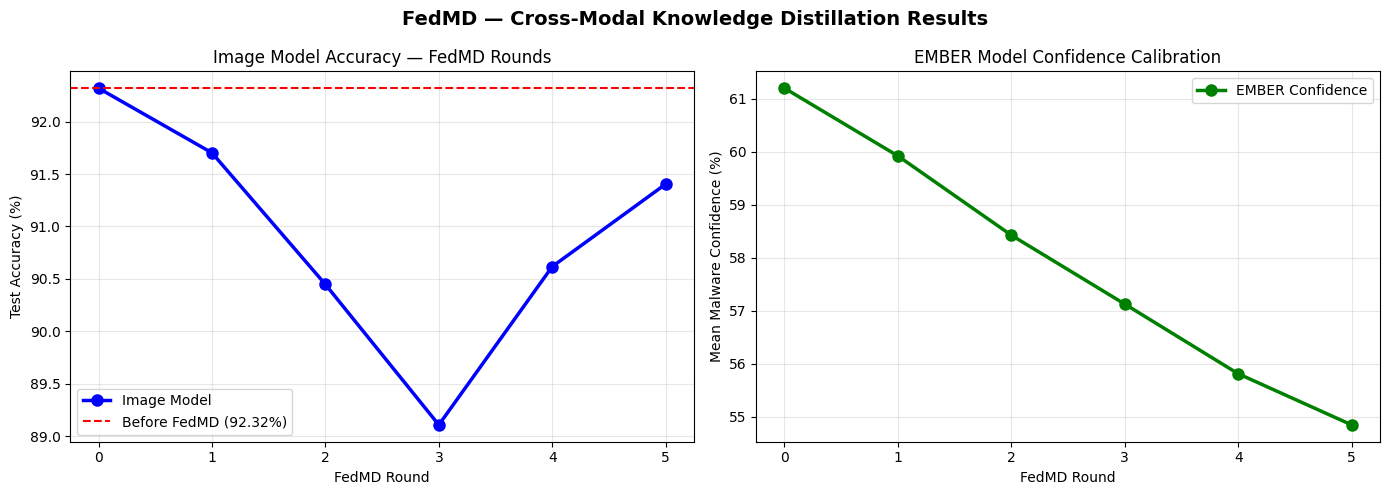

✅ Plot saved


In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('FedMD — Cross-Modal Knowledge Distillation Results', fontsize=14, fontweight='bold')

rounds = metrics['round']
img_accs = [a*100 for a in metrics['image_acc']]

axes[0].plot(rounds, img_accs, 'b-o', linewidth=2.5, markersize=8, label='Image Model')
axes[0].axhline(metrics['image_acc'][0]*100, color='red', linestyle='--',
                label=f'Before FedMD ({metrics["image_acc"][0]*100:.2f}%)')
axes[0].set_xlabel('FedMD Round')
axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_title('Image Model Accuracy — FedMD Rounds')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(rounds)

emb_confs = [a*100 for a in metrics['ember_mean_conf']]
axes[1].plot(rounds, emb_confs, 'g-o', linewidth=2.5, markersize=8, label='EMBER Confidence')
axes[1].set_xlabel('FedMD Round')
axes[1].set_ylabel('Mean Malware Confidence (%)')
axes[1].set_title('EMBER Model Confidence Calibration')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(rounds)

plt.tight_layout()
plt.savefig(f"{PATHS['output']}/fedmd_results.png", dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot saved')

SAMPLE OF EMBER PARQUET FOR DASHBOARD

In [13]:
# Run in Colab — creates small EMBER sample for local dashboard
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import joblib, json, os

OUTPUT = '/content/drive/MyDrive/FYP_Dashboard_Data/data'

# Load feature cols and scaler
with open('/content/drive/MyDrive/FYP_EMBER/fedavg_global_feature_cols.json') as f:
    feature_cols = json.load(f)

scaler = joblib.load(
    '/content/drive/MyDrive/FYP_EMBER/ember24_fedavg_global_scaler.pkl')

# Load parquet, select features, sample 500 rows
print('Loading parquet...')
df = pd.read_parquet(
    '/content/drive/MyDrive/FYP_EMBER/ember24_win64_test.parquet')

available = [c for c in feature_cols if c in df.columns]
df = df[available]
df = df.replace([np.inf, -np.inf], np.nan)
df = df.fillna(df.median(numeric_only=True))

# Save 500 raw rows (for showing feature values in dashboard)
sample_raw = df.sample(n=500, random_state=42)
feature_names = sample_raw.columns.tolist()

# Scale
X_raw   = sample_raw.values.astype(np.float32)
X_scaled = scaler.transform(X_raw)

# Save
np.save(f'{OUTPUT}/ember_test_sample_scaled.npy', X_scaled)
np.save(f'{OUTPUT}/ember_test_sample_raw.npy', X_raw)

with open(f'{OUTPUT}/ember_feature_names.json', 'w') as f:
    json.dump(feature_names, f)

print(f'✅ Saved {X_scaled.shape[0]} EMBER samples')
print(f'✅ Features: {X_scaled.shape[1]}')
print(f'   ember_test_sample_scaled.npy')
print(f'   ember_test_sample_raw.npy')
print(f'   ember_feature_names.json')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading parquet...
✅ Saved 500 EMBER samples
✅ Features: 890
   ember_test_sample_scaled.npy
   ember_test_sample_raw.npy
   ember_feature_names.json


In [14]:
import shutil

# Copy EMBER model to dashboard folder
shutil.copy2(
    '/content/drive/MyDrive/FYP_EMBER/ember24_fedavg_global_model.keras',
    '/content/drive/MyDrive/FYP_Dashboard_Data/models/ember24_fedavg_global_model.keras'
)
print('✅ EMBER model copied to dashboard folder')

✅ EMBER model copied to dashboard folder
